# Lista 5

## Pandas i Dask

(8pkt + 2pkt)

Na liście znajduje się 8 zadań. Po rozwiązaniu zadania pokaż kod prowadzącemu i odpowiedz na **pytanie kontrolne** — tylko wtedy przyznajemy punkty. Dodatkowo prześlij zadanie na platformie skos.

Zadanie dodatkowe oznaczone jest ⭐️. Za wykonanie zadania otrzymasz 2pkt.

### Pandas

Rozważ bazę danych z wykładu i rozwiąż poniższe zadania.

In [ ]:
import numpy as np
import pandas as pd

N = 100000

data_ = np.random.randint(1000, size=(N, 4))

df = pd.DataFrame(data_, columns=['time', 'uid', 'pid', 'rating'])
df['time'] = np.random.randint(24 * 60 * 60, size=(N))
df['time'] = pd.to_datetime('2025-01-01') + pd.to_timedelta(1e9 * df['time'])
df['rating'] = np.random.randint(10, size=(N))

df.head()

,time,uid,pid,rating
0,2025-01-01 16:17:37,189,737,1
1,2025-01-01 08:08:41,846,422,2
2,2025-01-01 23:00:45,657,965,0
3,2025-01-01 04:59:09,952,332,6
4,2025-01-01 05:25:28,540,734,7


#### Zadanie 1

Dla każdego użytkownika znajdź produkt (`pid`), który ocenił najczęściej.

In [ ]:
most_reviewed = df.groupby(['uid', 'pid'])[['rating']].count().reset_index()

most_reviewed.loc[most_reviewed.groupby('uid')['rating'].idxmax()]

,uid,pid,rating
4,0,58,2
112,1,155,2
232,2,485,2
286,3,78,2
404,4,350,2
...,...,...,...
94615,995,85,2
94749,996,380,2
94815,997,19,2
94929,998,160,2


#### Zadanie 2

Policz liczbę ocen w każdej godzinie dnia.

**Wskazówka**

Użyj `resample()`.

In [ ]:
df.resample('1h', on="time")['rating'].count()

,rating
time,
2025-01-01 00:00:00,4189
2025-01-01 01:00:00,4107
2025-01-01 02:00:00,4207
2025-01-01 03:00:00,4069
2025-01-01 04:00:00,4265
2025-01-01 05:00:00,4163
2025-01-01 06:00:00,4123
2025-01-01 07:00:00,4092
2025-01-01 08:00:00,4080


#### Zadanie 3

Wybierz oceny użytkowników w godzinach pracy: od 8:00 do 16:00. Następnie dla każdego produktu (`pid`) policz: liczbę ocen, średnią i maksymalną ocenę.

In [ ]:
df.set_index('time').between_time('8:00', '16:00').groupby('pid')['rating'].agg(['count', 'mean', 'max'])


,count,mean,max
pid,,,
0,26,4.192308,9
1,43,3.883721,9
2,29,5.275862,9
3,32,4.968750,9
4,34,4.205882,9
...,...,...,...
995,31,5.161290,9
996,30,3.633333,8
997,32,4.906250,9


#### Zadanie 4

Przekształć kolumnę `rating` na słowa:

* 0–3 → "niska"
* 4–6 → "średnia"
* 7–9 → "wysoka"

**Wskazówka**

Użyj `map()`.

In [ ]:
def rating_label(x):
    if x <= 3:
        return 'niska'
    elif x <= 6:
        return 'średnia'
    else:
        return 'wysoka'

df['rating_label'] = df['rating'].map(rating_label)
df


,time,uid,pid,rating,rating_label
0,2025-01-01 23:28:15,656,518,8,wysoka
1,2025-01-01 04:07:52,217,877,6,średnia
2,2025-01-01 17:26:24,700,552,3,niska
3,2025-01-01 07:15:23,937,356,0,niska
4,2025-01-01 15:44:55,126,477,3,niska
...,...,...,...,...,...
99995,2025-01-01 13:24:52,502,115,1,niska
99996,2025-01-01 04:39:50,170,718,4,średnia
99997,2025-01-01 14:12:59,320,900,3,niska
99998,2025-01-01 08:57:35,86,329,4,średnia


#### Zadanie 5

Połącz tabelę *products* zawierającą nazwy produktów (`pid` → `product_name`) z głównym df.

In [ ]:
products = pd.DataFrame({
    'pid': df['pid'].unique(),
    'product_name': ['Produkt_' + str(i) for i in range(len(df['pid'].unique()))]
})

df.merge(products, on='pid', how='inner')

,time,uid,pid,rating,rating_label,product_name
0,2025-01-01 23:28:15,656,518,8,wysoka,Produkt_0
1,2025-01-01 04:07:52,217,877,6,średnia,Produkt_1
2,2025-01-01 17:26:24,700,552,3,niska,Produkt_2
3,2025-01-01 07:15:23,937,356,0,niska,Produkt_3
4,2025-01-01 15:44:55,126,477,3,niska,Produkt_4
...,...,...,...,...,...,...
99995,2025-01-01 13:24:52,502,115,1,niska,Produkt_8
99996,2025-01-01 04:39:50,170,718,4,średnia,Produkt_839
99997,2025-01-01 14:12:59,320,900,3,niska,Produkt_13
99998,2025-01-01 08:57:35,86,329,4,średnia,Produkt_78


#### Zadanie 6

Policz, które produkty były najczęściej oceniane w poszczególnych godzinach. Zwizualizuj to na wykresie.

<Axes: xlabel='time'>

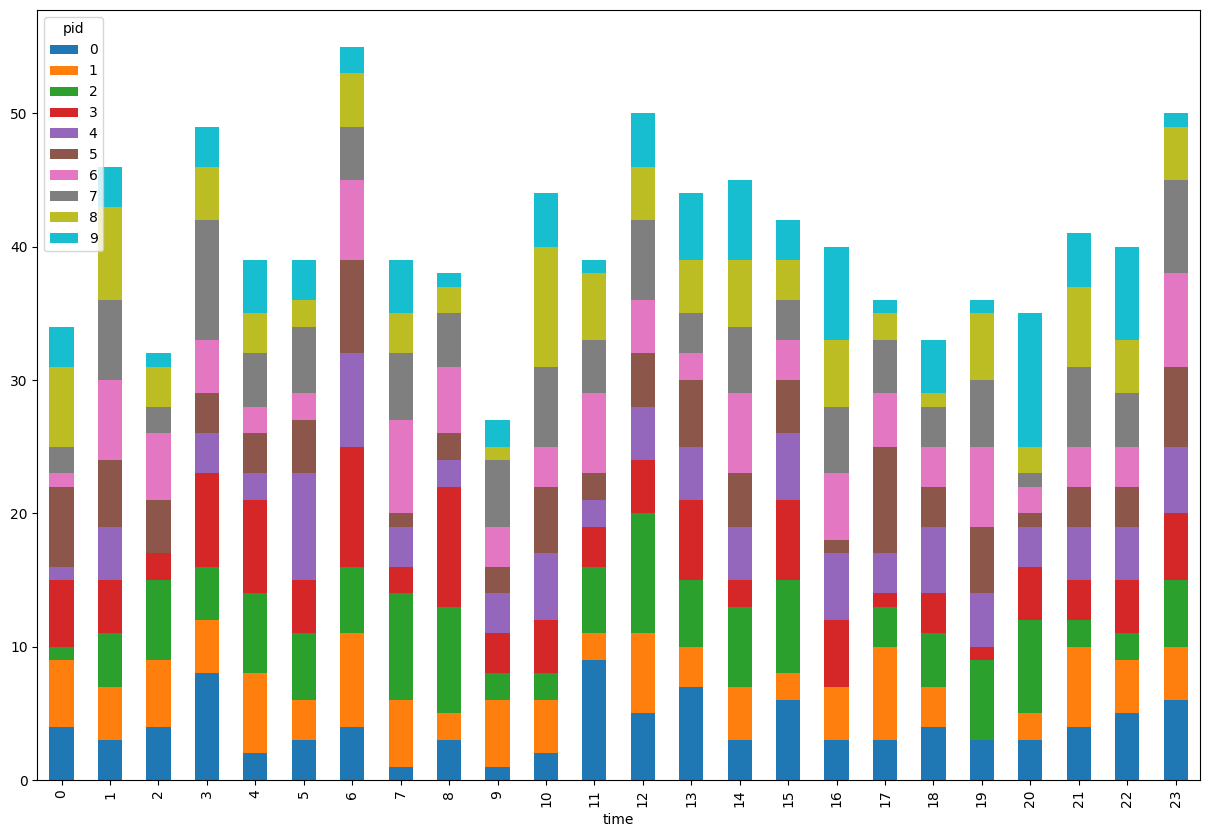

In [ ]:
df.groupby([df['time'].dt.hour, 'pid'])['rating'].count().unstack().iloc[:, :10].plot(kind='bar', stacked=True, figsize=(15, 10))

#### Zadanie 7

Utwórz dla każdego użytkownika sekwencję identyfikatorów produktów (`pid`), które ocenił, ale tylko produkty ocenione więcej niż 50 razy w godzinach od 8:00 do 16:00.

**Wskazówka**

Godzinę możesz wyodrębnić za pomocą:

```python
df['time'].dt.hour
```

In [ ]:
temp = df.set_index('time').between_time('8:00', '16:00').groupby('pid')['rating'].count()
temp = temp[temp > 50].index
df[df['pid'].isin(temp)].groupby('uid')['pid'].apply(list)

,pid
uid,
1,[804]
6,[969]
8,[969]
15,"[700, 919]"
17,[700]
...,...
989,[969]
990,[700]
993,[804]


#### Zadanie 8

Podziel produkty na 3 grupy według „stabilności ocen” (liczba ocen produktu) i policz średnią ocenę dla każdego użytkownika w kolejnych godzinach dnia, ale tylko dla produktów należących do 3. grupy (produkty z największą liczbą ocen).

**Wskazówka**

Może się przydać funkcja `qcut()`, `merge()`.

In [ ]:
stable = pd.qcut(df.groupby('pid')['rating'].count(), 3, labels=False)
df = df[df['pid'].isin(stable[stable == 2].index)]
df.groupby(['pid', df['time'].dt.hour])['rating'].mean().unstack()


time,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pid,,,,,,,,,,,,,,,,,,,,,
12,3.500000,4.500000,3.000000,3.400000,4.000000,6.000000,2.500000,4.000000,8.000000,3.000000,...,6.416667,2.500000,3.833333,4.833333,3.000000,5.200000,3.400000,4.750000,4.571429,2.400000
13,6.166667,6.800000,6.000000,3.666667,6.500000,3.857143,5.444444,4.000000,7.500000,4.000000,...,2.166667,4.000000,3.857143,4.333333,6.000000,9.000000,7.500000,5.142857,4.666667,3.000000
19,3.750000,3.500000,2.428571,5.571429,5.142857,5.000000,5.600000,6.000000,5.600000,5.333333,...,5.833333,2.666667,5.333333,7.666667,4.500000,4.818182,2.500000,5.700000,1.750000,3.571429
34,4.333333,5.166667,4.750000,3.250000,3.500000,4.000000,NaN,7.000000,3.875000,3.000000,...,4.142857,5.333333,6.250000,5.333333,1.000000,2.600000,2.444444,3.000000,5.666667,4.000000
38,7.000000,3.000000,3.000000,3.333333,8.000000,3.500000,3.428571,2.500000,4.250000,3.166667,...,2.833333,4.250000,3.500000,4.000000,4.625000,2.833333,1.333333,5.200000,5.333333,7.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,7.250000,5.333333,1.500000,4.666667,5.000000,5.600000,5.000000,2.857143,2.666667,3.000000,...,4.750000,2.500000,5.200000,7.000000,3.857143,4.750000,3.750000,4.714286,3.750000,5.000000
969,3.500000,6.666667,5.000000,5.000000,1.666667,5.750000,5.500000,5.285714,3.444444,2.333333,...,5.625000,5.000000,4.200000,7.666667,4.600000,2.500000,6.500000,3.666667,8.000000,3.000000
977,4.000000,5.714286,7.000000,4.400000,3.125000,5.333333,2.500000,5.000000,6.666667,5.666667,...,3.333333,4.800000,3.333333,6.200000,5.666667,4.800000,5.800000,5.000000,5.000000,5.250000


### ⭐️ Dask

Wygenerujemy dane syntetyczne w Pandas i zapiszemy je do CSV.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1_000_000

df = pd.DataFrame({
    "uid": np.random.randint(1, 100_000, size=n),
    "movie_id": np.random.randint(1, 5000, size=n),
    "rating": np.random.uniform(1, 5, size=n).round(2),
    "timestamp": pd.date_range("2020-01-01", periods=n, freq="min")
})

df.to_csv("ratings.csv", index=False)
print("Zapisano plik: ratings.csv")

Zapisano plik: ratings.csv


#### Zadanie 1

Wczytaj dane z pliku *ratings.csv* do Dask DataFrame. Ile partycji ma wczytany plik? Sprawdź rozmiar danych (`memory_usage()`)

In [3]:
from dask.distributed import Client
import dask.dataframe as dd
client = Client()  # start distributed scheduler locally.
client

/usr/local/lib/python3.12/dist-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42433 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:36903
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:42433/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:41649'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37121'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:46499 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:46499
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:58688
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:40697 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40697
IN

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42433/status,
Dashboard: http://127.0.0.1:42433/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36903,Workers: 0
Dashboard: http://127.0.0.1:42433/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40697,Total threads: 1
Dashboard: http://127.0.0.1:33355/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:41649,


In [7]:
ddf = dd.read_csv('ratings.csv')
ddf.npartitions

1

In [8]:
ddf.memory_usage()

Dask Series Structure:
npartitions=1
    int64
      ...
Dask Name: memoryusageframe, 3 expressions
Expr=ArrowStringConversion(frame=FromMapProjectable(6bc7ed6)).memoryusageframe()

#### Zadanie 2

Oblicz średnią ocenę oraz policz liczbę ocen > 4.

In [11]:
# ddf['rating'].mean().compute()
ddf.rating.mean().compute()

np.float64(2.9993551000000003)

In [13]:
(ddf.rating > 4).sum().compute()

np.int64(248540)

#### Zadanie 3

Pokaż, jak Dask rozkłada obliczenia na taski dla operacji:

```python
ddf.groupby("uid")["rating"].mean()
```

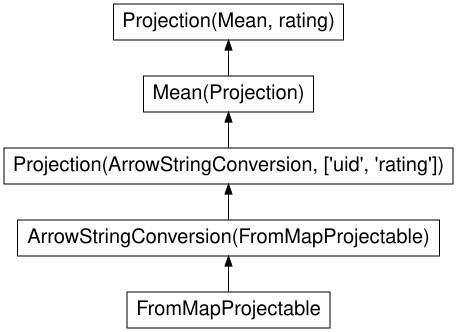

In [15]:
res = ddf.groupby("uid")["rating"].mean()
res.visualize()

#### Zadanie 4

Znajdź 10 filmów z najwyższą średnią oceną (tylko jeśli mają >100 ocen). Niech wynik będzie zapisany w pamięci.

In [46]:
temp = ddf.groupby('movie_id')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False).persist()
temp[temp['count'] > 100].persist().head(10)

,mean,count
movie_id,,
621,3.353220,205
4224,3.331755,188
3736,3.293943,175
1048,3.293280,186
1500,3.284029,206
1417,3.274503,191
1626,3.273962,212
1735,3.272353,204
1227,3.271968,188
